<a href="https://colab.research.google.com/github/mbaker21231/MicroII-Sandbox/blob/main/Principal_and_Agent_LP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal and Agent

We are going to cast the problem as a linear programming problem and see what the optimal contract looks like. We will ignore risk aversion and just focus on the problem:

$$
\max \sum_{i=1}^N (S_i-w_i)p_{ih}
$$
subject to (IC constraint):

$$
\sum_{i=1}^N w_ip_{ih} - c \geq \sum_{i=1}^N w_ip_{il}
$$
and (IR or P constraint):
$$
\sum_{i=1}^N w_ip_{ih} - c \geq \bar u
$$

The principal, that is, is trying to maximize surplus subject to the incentive compatibility and participation constraints of the agent.

In linear programming speak, this is the same as minimizing:

$$
w'p_h
$$
subject to
$$
w'p_h\geq w'p_l+c
$$
$$
w'p_h \geq \bar u + c
$$

Here is some python that solves the problem, given two constants $c$ and $u$, and vectors $p_h$ and $p_l$.

In [2]:
import numpy as np
from scipy.optimize import linprog

# Given vectors and constants
h = np.array([.1, .2, .3, .4])  # Vector h
l = np.array([.4, .3, .2, .1])  # Vector l
c = 1  # Given constant c
u = 1  # Given constant u

# Number of variables (length of w)
n = len(h)

# Define constraints: A w ≤ b
A = np.vstack([- (h - l), -h])  # Constraint matrix
b = np.array([-c, -(u + c)])  # Right-hand side

# Solve the linear program for w
res = linprog(c=h, A_ub=A, b_ub=b, method='highs')

# Display results
if res.success:
    print("Optimal solution found:")
    print("w =", res.x)
    print("Minimum value of w'h:", res.fun)
else:
    print("Optimization failed:", res.message)

Optimal solution found:
w = [0. 0. 0. 5.]
Minimum value of w'h: 2.0


It's kind of fun to draw a graph of the result, so we can see what how everything changes with different probabilities. Here goes:

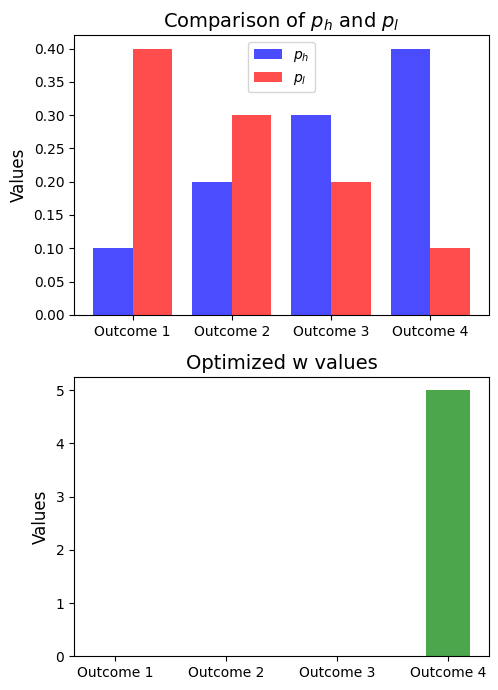

In [6]:
import matplotlib.pyplot as plt

# Labels for the bars
labels = [f"Outcome {i+1}" for i in range(len(h))]

# Set up figure and subplots
fig, axs = plt.subplots(2, 1, figsize=(5, 7))  # Two vertically stacked subplots

# Bar width for side-by-side comparison
bar_width = 0.4
x = np.arange(len(h))  # X positions for bars

# Top Bar Chart: h and l side by side
axs[0].bar(x - bar_width/2, h, bar_width, label='$p_h$', color='blue', alpha=0.7)
axs[0].bar(x + bar_width/2, l, bar_width, label='$p_l$', color='red', alpha=0.7)
axs[0].set_title("Comparison of $p_h$ and $p_l$", fontsize=14)
axs[0].set_ylabel("Values", fontsize=12)
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels, fontsize=10)
axs[0].legend()

# Bottom Bar Chart: w values
axs[1].bar(x, res.x, bar_width, color='green', alpha=0.7)
axs[1].set_title("Optimized w values", fontsize=14)
axs[1].set_ylabel("Values", fontsize=12)
axs[1].set_xticks(x)
axs[1].set_xticklabels(labels, fontsize=10)

# Improve layout and display
plt.tight_layout()
plt.show()

Evidently, we just stack up all the wages on the highest outcome, and let everything else be zero. We see that .4*5=2, which is 1 + 1 as well. What about a nuanced example? Here is some code that overlays a log-normal distribution on a fixed set of grid points:

In [7]:
from scipy.stats import lognorm


def approximate_lognormal(grid, mean, std):
    """
    Approximates a log-normal distribution over a given grid of points.

    Parameters:
    - grid: numpy array, the grid of points where the distribution is evaluated.
    - mean: float, the desired mean of the log-normal distribution.
    - std: float, the desired standard deviation of the log-normal distribution.

    Returns:
    - probabilities: numpy array, the probability mass function approximated on the grid.
    """
    # Convert mean and std to log-normal parameters
    mu = np.log(mean**2 / np.sqrt(std**2 + mean**2))
    sigma = np.sqrt(np.log(1 + (std**2 / mean**2)))

    # Compute probability densities on the given grid
    pdf_values = lognorm.pdf(grid, s=sigma, scale=np.exp(mu))

    # Normalize to approximate a probability mass function (PMF)
    probabilities = pdf_values / np.sum(pdf_values)

    return probabilities

Now, what we can do is get the "high" probabilities on these points and the "low" probabilities on these points:

In [15]:
grid = np.linspace(0.1, 10, 50)  # Define the grid (avoid zero to prevent log issues)

meanh = 2.0  # Example mean for the high-effort level
stdh = 0.5   # Example standard deviation for the high-effort level

meanl = 1.6 # Same as above, but for the low-effort level
stdl  = 0.95

# Compute probabilities
h = approximate_lognormal(grid, meanh, stdh)
l = approximate_lognormal(grid, meanl, stdl)

u=2    # Reservation utility
c=3    # Cost of effort

n = len(h)

# Define constraints: A w ≤ b
A = np.vstack([- (h - l), -h])  # Constraint matrix
b = np.array([-c, -(u + c)])  # Right-hand side

# Solve the linear program for w
res = linprog(c=h, A_ub=A, b_ub=b, method='highs')

# Display results
if res.success:
    print("Optimal solution found:")
    print("w =", res.x)
    print("Minimum value of w'h:", res.fun)
else:
    print("Optimization failed:", res.message)

Optimal solution found:
w = [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         44.09198582
  0.          0.          0.         15.1177354   0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]
Minimum value of w'h: 5.0


Interesting how that works out - do we always just get a spike?

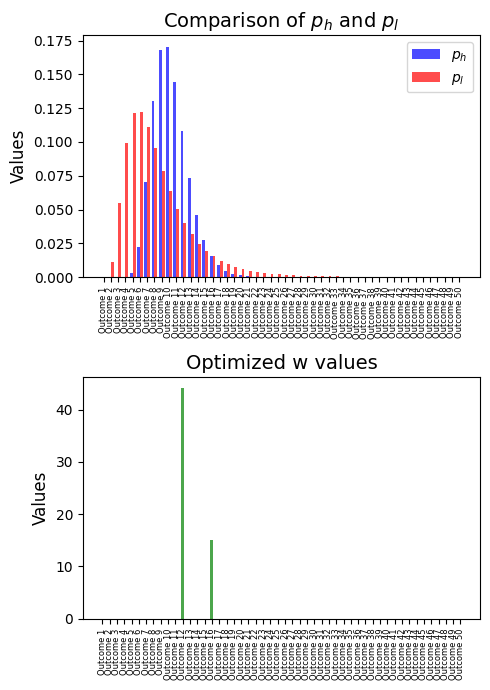

In [16]:

# Labels for the bars
labels = [f"Outcome {i+1}" for i in range(len(h))]

# Set up figure and subplots
fig, axs = plt.subplots(2, 1, figsize=(5, 7))  # Two vertically stacked subplots

# Bar width for side-by-side comparison
bar_width = 0.4
x = np.arange(len(h))  # X positions for bars

# Top Bar Chart: h and l side by side
axs[0].bar(x - bar_width/2, h, bar_width, label='$p_h$', color='blue', alpha=0.7)
axs[0].bar(x + bar_width/2, l, bar_width, label='$p_l$', color='red', alpha=0.7)
axs[0].set_title("Comparison of $p_h$ and $p_l$", fontsize=14)
axs[0].set_ylabel("Values", fontsize=12)
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels, rotation=90, fontsize=6)
axs[0].legend()

# Bottom Bar Chart: w values
axs[1].bar(x, res.x, bar_width, color='green', alpha=0.7)
axs[1].set_title("Optimized w values", fontsize=14)
axs[1].set_ylabel("Values", fontsize=12)
axs[1].set_xticks(x)
axs[1].set_xticklabels(labels, rotation=90, fontsize=6)

# Improve layout and display
plt.tight_layout()
plt.show()

In [ ]:
plt.xticks(rotation=45, fontsize=10)